# Data Preprocessing

In this notebook, we  perform exploratory data analysis and clean the our dataset. The main output of this task is to create our cleaned training and test dataset.

### Imports & Setup

We start by importing the libraries we will be using to process our dataset. We used the library Natural Language Toolkit (nltk) because we are interested in processing news articles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split

# Download required NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("All imports successful.")

All imports successful.


### Loading dataset and Assigning Labels

We then load our two csv files, `Fake.csv` and `True.csv`, on a dataframe and assign a label `0` for the fake news samples and `1` for the true news. We then concatenate both dataframes before performing our analysis.

In [2]:
fake_df = pd.read_csv("Dataset/fake.csv")
true_df = pd.read_csv("Dataset/true.csv")

fake_df["label"] = 0
true_df["label"] = 1

df = pd.concat([fake_df, true_df], ignore_index=True)

print(f"Fake samples : {len(fake_df)}")
print(f"True samples : {len(true_df)}")
print(f"Total samples: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nShape: {df.shape}")
df.head()

Fake samples : 23481
True samples : 21417
Total samples: 44898

Columns: ['title', 'text', 'subject', 'date', 'label']

Shape: (44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


### Feature Types and Distributions

We then explore the data types of the featuers. We find that the text features are of type object. We then display the distribution analysis of the two features, `title` and `text` by their length. We do this by creating additional features that save each sample's title and text length respectively.

In [3]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Basic Stats (text length) ===")
df["text_len"] = df["text"].astype(str).apply(len)
df["title_len"] = df["title"].astype(str).apply(len)
print(df[["text_len", "title_len"]].describe().round(1))

print("\n=== Label Distribution ===")
print(df["label"].value_counts().rename({0: "Fake", 1: "True"}))

print("\n=== Subject Distribution ===")
print(df["subject"].value_counts())

=== Data Types ===
title      object
text       object
subject    object
date       object
label       int64
dtype: object

=== Basic Stats (text length) ===
       text_len  title_len
count   44898.0    44898.0
mean     2469.1       80.1
std      2171.6       25.4
min         1.0        8.0
25%      1234.0       63.0
50%      2186.0       73.0
75%      3105.0       91.0
max     51794.0      286.0

=== Label Distribution ===
label
Fake    23481
True    21417
Name: count, dtype: int64

=== Subject Distribution ===
subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


### Missing Values & Duplicates

Next, we check for missing and duplicated samples. There are no null values, but we find that we have 209 duplicate rows and 631 rows that contain empty strings or only whitespaces for either title or text feature. Since our dataset is large, dropping these rows doesn't affect our model training.

In [4]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")

if n_dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Dropped duplicates. New shape: {df.shape}")
else:
    print("No duplicates found.")

# Drop rows where text or title is empty/whitespace
before = len(df)
df = df[df["text"].str.strip().astype(bool) & df["title"].str.strip().astype(bool)]
df = df.reset_index(drop=True)
print(f"\nRows removed due to empty text/title: {before - len(df)}")
print(f"Final shape: {df.shape}")

=== Missing Values ===
title        0
text         0
subject      0
date         0
label        0
text_len     0
title_len    0
dtype: int64

=== Duplicate Rows ===
Duplicate rows: 209
Dropped duplicates. New shape: (44689, 7)

Rows removed due to empty text/title: 631
Final shape: (44058, 7)


### Exploratory Analysis Plots

We then show the analysis of the features and the labels of our dataset using plots. We show:
- The sample balance between the two classes
- Title and Text length distribution for each labels using histograms

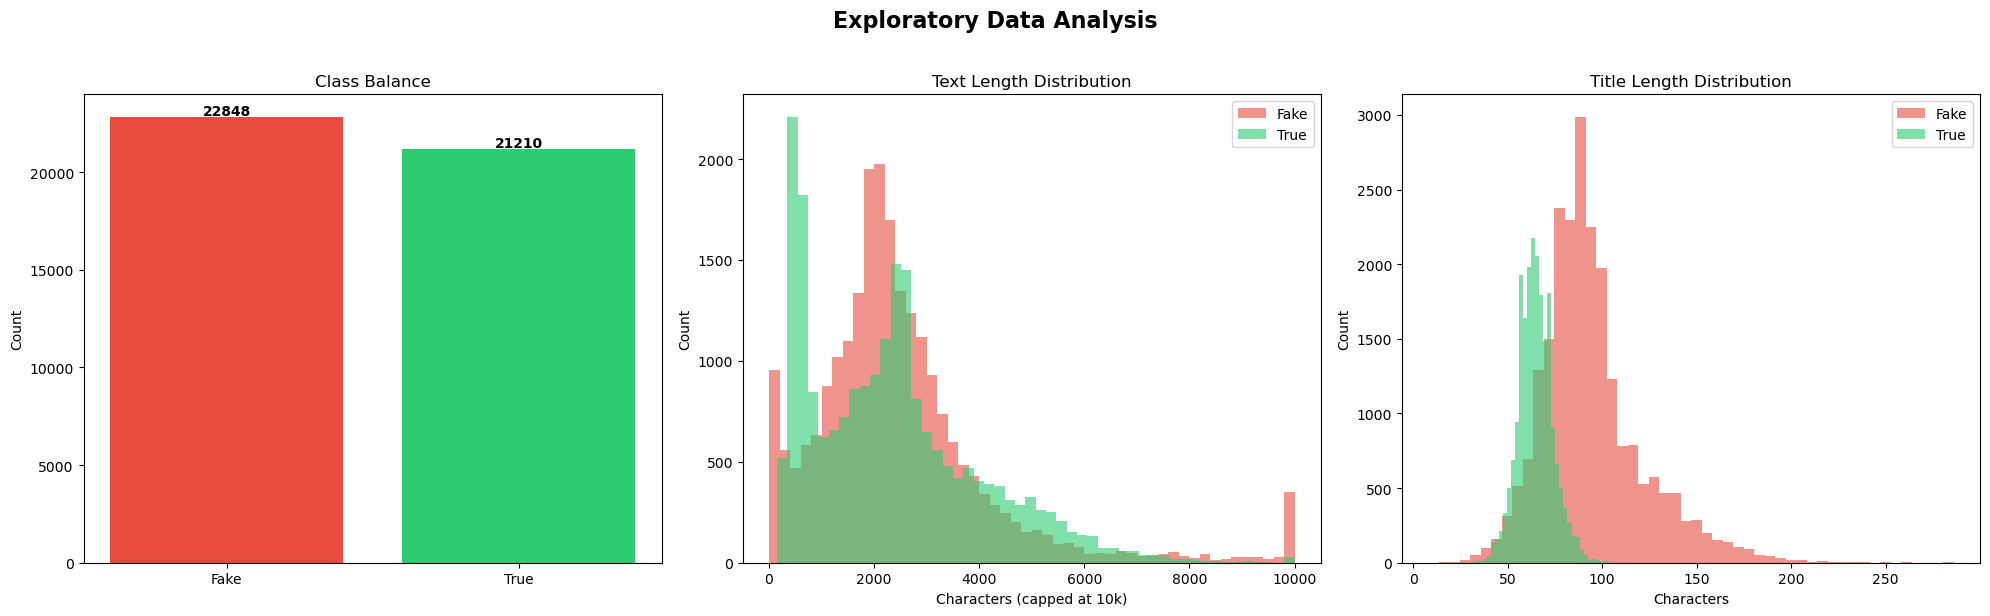

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Exploratory Data Analysis", fontsize=16, fontweight="bold", y=1.02)

# 1. Class balance
label_counts = df["label"].value_counts().rename({0: "Fake", 1: "True"})
axes[0].bar(label_counts.index, label_counts.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Class Balance")
axes[0].set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha="center", fontweight="bold")

# 2. Text length distribution by label
for label, color, name in [(0, "#e74c3c", "Fake"), (1, "#2ecc71", "True")]:
    subset = df[df["label"] == label]["text_len"]
    axes[1].hist(subset.clip(upper=10000), bins=50, alpha=0.6, color=color, label=name)
axes[1].set_title("Text Length Distribution")
axes[1].set_xlabel("Characters (capped at 10k)")
axes[1].set_ylabel("Count")
axes[1].legend()

# 3. Title length distribution by label
for label, color, name in [(0, "#e74c3c", "Fake"), (1, "#2ecc71", "True")]:
    subset = df[df["label"] == label]["title_len"]
    axes[2].hist(subset, bins=50, alpha=0.6, color=color, label=name)
axes[2].set_title("Title Length Distribution")
axes[2].set_xlabel("Characters")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.savefig("./plots/eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()

From the plots, we see that the mean title character counts for the fake news samples is considerably longer than the true samples.

### Text cleaning function definition

The purpose of cleaning our samples is to remove noise and bias to irrelevant data when training model. To clean the articles, the main techniques used were:

- Standardizing to lowercase
- Removing Hashtags, URLs and Handles to help model focus on the actual linguistic style of the article
- Removing stopwords like "is" and "and" that happen frequently and don't add ainformation to the model
- Lemmatization to reduce words to their root ("running" and "ran" to "run") which is useful for word frequency analysis.
- Removing photo credits to remove bias based on the photographers in the training dataset 

In [12]:
STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    # Remove URLs (http, https, www, pic.twitter.com, etc.)
    text = re.sub(r"http\S+|www\S+|pic\.twitter\S+", "", text)
    # Remove Twitter handles (@username)
    text = re.sub(r"@\w+", "", text)
    # Remove hashtags (#topic)
    text = re.sub(r"#\w+", "", text)
    # Remove photo credits (e.g. "Photo by Getty Images", "Photo by Name/Agency")
    text = re.sub(r"photo by [^\.\n]+", "", text)
    # Remove punctuation and digits
    text = re.sub(r"[^a-z\s]", "", text)
    # Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS]
    return " ".join(tokens)

sample = df["text"].iloc[0]
print("ORIGINAL:\n", sample[:300])
print("\nCLEANED:\n", clean_text(sample)[:300])


ORIGINAL:
 Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger a

CLEANED:
 donald trump wish american happy new year leave instead give shout enemy hater dishonest fake news medium former reality show star one job country rapidly grows stronger smarter want wish friend supporter enemy hater even dishonest fake news medium happy healthy new year president angry pant tweeted


### Cleaning Title and Text features

New feature columns are then added to our dataframe for the cleaned text and title samples. 

In [13]:
print("Cleaning text column...")
df["cleaned_text"] = df["text"].apply(clean_text)

print("Cleaning title column...")
df["cleaned_title"] = df["title"].apply(clean_text)

print("Done!")
print(df[["title", "cleaned_title", "text", "cleaned_text"]].head(3))

Cleaning text column...
Cleaning title column...
Done!
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   

                                       cleaned_title  \
0  donald trump sends embarrassing new year eve m...   
1  drunk bragging trump staffer started russian c...   
2  sheriff david clarke becomes internet joke thr...   

                                                text  \
0  Donald Trump just couldn t wish all Americans ...   
1  House Intelligence Committee Chairman Devin Nu...   
2  On Friday, it was revealed that former Milwauk...   

                                        cleaned_text  
0  donald trump wish american happy new year leav...  
1  house intelligence committee chairman devin nu...  
2  friday revealed former milwaukee sheriff david...  


### Stratified Train/Test split

Stratified split keeps the class distribution of the original data after split. If original data was 90-10 (T/F), both training and test data samples will also have 90-10 (T/F) distribution.

We add a new content feature that merges the cleaned text and title to the dataframe that helps for feature selection later on. The dataframe is then split to 75% training data and 25% test data by stratifying the label.

Finally, the training and test csv files are shuffled and exported for the next task.

In [14]:
# Combine cleaned title + text into one field for modeling
df["content"] = df["cleaned_title"] + " " + df["cleaned_text"]

# Stratified 75/25 split per class
train_df, test_df = train_test_split(
    df[["title", "text", "cleaned_title", "cleaned_text", "content", "label"]],
    test_size=0.25,
    random_state=42,
    stratify=df["label"]
)

# Shuffle
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df  = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Train size : {len(train_df)}")
print(f"Test size  : {len(test_df)}")
print(f"\nTrain label distribution:\n{train_df['label'].value_counts().rename({0:'Fake',1:'True'})}")
print(f"\nTest label distribution:\n{test_df['label'].value_counts().rename({0:'Fake',1:'True'})}")

# Export
train_df.to_csv("Dataset/train.csv", index=False)
test_df.to_csv("Dataset/test.csv", index=False)
print("\nExported train.csv and test.csv to Dataset/")


Train size : 33043
Test size  : 11015

Train label distribution:
label
Fake    17136
True    15907
Name: count, dtype: int64

Test label distribution:
label
Fake    5712
True    5303
Name: count, dtype: int64

Exported train.csv and test.csv to Dataset/


### Summary

In [15]:
print("=" * 55)
print("       NOTEBOOK 1 — PREPROCESSING SUMMARY")
print("=" * 55)

print(f"""
DATASET
-------
  Source files     : fake.csv, true.csv
  Raw samples      : 44,898  (Fake: 23,481 | True: 21,417)
  Duplicates removed     : {44898 - len(df) + (44898 - 44689)}
  Empty rows removed     : 631
  Final samples          : {len(df)}

CLEANING PIPELINE
-----------------
  1. Lowercased all text
  2. Removed URLs (http, https, pic.twitter.com)
  3. Removed Twitter handles (@username)
  4. Removed hashtags (#topic)
  5. Removed photo credits (Photo by ...)
  6. Removed punctuation and digits
  7. Removed English stopwords (NLTK)
  8. Applied WordNet lemmatization

FEATURES CREATED
----------------
  cleaned_text   : cleaned body text
  cleaned_title  : cleaned article title
  content        : cleaned_title + cleaned_text (combined)

SPLIT
-----
  Strategy  : Stratified 75/25 by label
  Train set : {len(train_df)} samples
  Test set  : {len(test_df)} samples
  Exported  : data/train.csv, data/test.csv
""")
print("=" * 55)


       NOTEBOOK 1 — PREPROCESSING SUMMARY

DATASET
-------
  Source files     : fake.csv, true.csv
  Raw samples      : 44,898  (Fake: 23,481 | True: 21,417)
  Duplicates removed     : 1049
  Empty rows removed     : 631
  Final samples          : 44058

CLEANING PIPELINE
-----------------
  1. Lowercased all text
  2. Removed URLs (http, https, pic.twitter.com)
  3. Removed Twitter handles (@username)
  4. Removed hashtags (#topic)
  5. Removed photo credits (Photo by ...)
  6. Removed punctuation and digits
  7. Removed English stopwords (NLTK)
  8. Applied WordNet lemmatization

FEATURES CREATED
----------------
  cleaned_text   : cleaned body text
  cleaned_title  : cleaned article title
  content        : cleaned_title + cleaned_text (combined)

SPLIT
-----
  Strategy  : Stratified 75/25 by label
  Train set : 33043 samples
  Test set  : 11015 samples
  Exported  : data/train.csv, data/test.csv

